# Задание 1. Прогноз сердечно-сосудистого риска

Предсказываем `prediction` (0 = низкий риск, 1 = высокий) по клиническим признакам пациента.
Модель — нейросеть: 1 скрытый слой, 32 нейрона, ReLU, 150 эпох.
Результат — `outputs/task1_predictions.csv` со столбцами `patient_id`, `prediction`.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, log_loss, confusion_matrix)

SEED = 42  # чтобы результат повторялся

**1–2. Скачать данные и загрузить CSV в pandas**

Если ноутбук запущен в репозитории — читаем локальные файлы, иначе (например, в Colab) — скачиваем с GitHub.

In [2]:
repo_root = Path.cwd()
if repo_root.name == 'your-sollution':
    repo_root = repo_root.parent


def dataset_path(filename):
    local = repo_root / 'dataset' / 'task1' / filename
    if local.exists():
        return str(local)
    return ('https://github.com/AI-is-out-there/check-your-biomed-datascience-skills-review/'
            f'raw/refs/heads/dev/dataset/task1/{filename}')


train = pd.read_csv(dataset_path('train.csv'))
test = pd.read_csv(dataset_path('test_features.csv'))
print('train:', train.shape, ' test_features:', test.shape)

train: (800, 19)  test_features: (200, 18)


**Вывод:** в train 800 пациентов и 19 столбцов, в `test_features` — 200 пациентов и 18 столбцов (нет только `prediction`, его и надо предсказать).

**Признаки и цель**

Цель — `prediction`. `Статус_глюкозы` и `Доклинический_риск` — тоже метки (другие задачи), поэтому в признаки их не берём.
`patient_id` — просто номер. Остаётся 15 клинических признаков.

In [3]:
TARGET = 'prediction'
DROP = ['patient_id', 'prediction', 'Статус_глюкозы', 'Доклинический_риск']
FEATURES = [c for c in train.columns if c not in DROP]

X = train[FEATURES]
y = train[TARGET]
print(len(FEATURES), 'признаков')
print('Доля высокого риска:', round(y.mean(), 3))

15 признаков
Доля высокого риска: 0.181


**Вывод:** для модели 15 признаков. Высокий риск только у 18% пациентов — классы несбалансированы, модель может чаще ошибаться на больных.

**6. Разделить на train / val / test**

Делим сразу, до всей обработки: выбросы, средние и масштаб считаем только по train,
иначе модель «подсмотрит» в val и test. Пропорции 60 / 20 / 20, `stratify` сохраняет долю больных в каждой части.

In [4]:
X_trval, X_test, y_trval, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=SEED)
X_train, X_val, y_train, y_val = train_test_split(X_trval, y_trval, test_size=0.25, stratify=y_trval, random_state=SEED)
print('train:', len(X_train), ' val:', len(X_val), ' test:', len(X_test))

train: 480  val: 160  test: 160


**Вывод:** 480 пациентов на обучение, по 160 на val и test. Благодаря `stratify` доля больных (~18%) одинакова во всех частях.

**3. Убрать выбросы (z-score)**

z-score — на сколько стандартных отклонений значение далеко от среднего. Строку считаем выбросом, если хоть один признак дальше 3.
Убираем только из train: в val, test и `test_features` нужен прогноз для каждого пациента.

IQR (1.5 × межквартильный размах) не взяли: он убирал 23 строки, почти половина из них — больные, то есть выкидывал полезные данные.

In [5]:
num_cols = [c for c in FEATURES if c not in ['Пол_мужской', 'Курение']]  # у 0/1 признаков выбросов нет

z = (X_train[num_cols] - X_train[num_cols].mean()) / X_train[num_cols].std()
outlier = (z.abs() > 3).any(axis=1)  # NaN даёт False, пропуски выбросом не считаются

X_train, y_train = X_train[~outlier], y_train[~outlier]
print('Удалено выбросов:', outlier.sum(), '| осталось в train:', len(X_train))

Удалено выбросов: 9 | осталось в train: 471


**Вывод:** выбросов мало — 9 строк из 480 (2%). Данные в основном чистые, обучение почти не теряет данных.

**4. Заполнить пропуски средним**

Пропуски есть в ЛПНП, ЛПВП, триглицеридах и СКФ (4–6% строк). Среднее считаем по train и им же заполняем все остальные части.

In [6]:
print('Пропуски в train:')
print(X_train.isna().sum().loc[lambda s: s > 0])

train_mean = X_train.mean()
X_train = X_train.fillna(train_mean)
X_val = X_val.fillna(train_mean)
X_test = X_test.fillna(train_mean)
print('Пропусков после заполнения:', X_train.isna().sum().sum() + X_val.isna().sum().sum() + X_test.isna().sum().sum())

Пропуски в train:
ЛПНП_ммоль_л            21
ЛПВП_ммоль_л            20
Триглицериды_ммоль_л    28
СКФ_мл_мин              30
dtype: int64
Пропусков после заполнения: 0


**Вывод:** пропуски были только в 4 лабораторных показателях (20–30 из 471 строки, 4–6%). После заполнения средним их нет ни в одной части.

**5. Нормализовать через StandardScaler**

Приводим каждый признак к среднему 0 и стандартному отклонению 1. Иначе признаки с большими числами
(СКФ ~100) заглушат маленькие (HbA1c ~5), и сеть будет учиться хуже. `fit` — только на train.

In [7]:
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_val_s = scaler.transform(X_val)
X_test_s = scaler.transform(X_test)
print('Средние признаков на train: от', X_train_s.mean(axis=0).min().round(2), 'до', X_train_s.mean(axis=0).max().round(2))
print('Std признаков на train: от', X_train_s.std(axis=0).min().round(2), 'до', X_train_s.std(axis=0).max().round(2))

Средние признаков на train: от -0.0 до 0.0
Std признаков на train: от 1.0 до 1.0


**Вывод:** после нормализации у всех признаков среднее 0 и std 1 — они в одной шкале, ни один не «перевешивает» другие из-за единиц измерения.

**7. Обучить модель: 1 слой, 32 нейрона, ReLU, 150 эпох**

`MLPClassifier` из sklearn — полносвязная нейросеть. Один вызов `partial_fit` = одна эпоха (один проход по train).
После каждой эпохи записываем ошибку (log loss) на train и val, чтобы увидеть, не переобучается ли сеть.

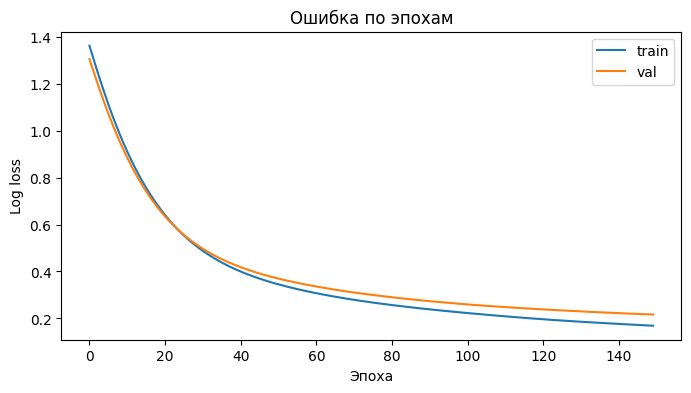

Log loss после 150 эпох: train 0.169, val 0.217


In [8]:
model = MLPClassifier(hidden_layer_sizes=(32,), activation='relu', random_state=SEED)

EPOCHS = 150
train_loss, val_loss = [], []
for epoch in range(EPOCHS):
    model.partial_fit(X_train_s, y_train, classes=[0, 1])
    train_loss.append(log_loss(y_train, model.predict_proba(X_train_s)))
    val_loss.append(log_loss(y_val, model.predict_proba(X_val_s)))

plt.figure(figsize=(8, 4))
plt.plot(train_loss, label='train')
plt.plot(val_loss, label='val')
plt.xlabel('Эпоха')
plt.ylabel('Log loss')
plt.title('Ошибка по эпохам')
plt.legend()
plt.show()
print(f'Log loss после {EPOCHS} эпох: train {train_loss[-1]:.3f}, val {val_loss[-1]:.3f}')

**Вывод:** ошибка на train и val падает вместе и к 150-й эпохе почти выходит на плато. Val не растёт — переобучения нет, 150 эпох достаточно.

**Оценка качества**

- *Recall* — какую долю больных нашли.
- *Specificity* — какую долю здоровых правильно назвали здоровыми.
- *Precision* — какая доля «тревог» оказалась настоящей.
- *F1* — среднее Precision и Recall.
- *ROC-AUC* — насколько хорошо модель отделяет больных от здоровых: 0.5 — случайно, 1 — идеально.

In [9]:
def evaluate(X_part, y_part):
    proba = model.predict_proba(X_part)[:, 1]
    pred = (proba >= 0.5).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_part, pred).ravel()
    return {'Accuracy': accuracy_score(y_part, pred), 'Recall': recall_score(y_part, pred),
            'Specificity': tn / (tn + fp), 'Precision': precision_score(y_part, pred),
            'F1': f1_score(y_part, pred), 'ROC-AUC': roc_auc_score(y_part, proba),
            'Пропущено больных (FN)': fn, 'Ложные тревоги (FP)': fp}


pd.DataFrame({'val': evaluate(X_val_s, y_val), 'test': evaluate(X_test_s, y_test)}).round(3)

,val,test
Accuracy,0.912,0.931
Recall,0.690,0.759
Specificity,0.962,0.969
Precision,0.800,0.846
F1,0.741,0.800
ROC-AUC,0.958,0.960
Пропущено больных (FN),9.000,7.000
Ложные тревоги (FP),5.000,4.000


**Вывод:** ROC-AUC 0.96 — модель хорошо отличает больных от здоровых. Здоровых узнаёт почти всех (Specificity 0.97), а больных хуже: Recall 0.76 на test и 0.69 на val, то есть пропущено 7 и 9 больных из 29. Это следствие дисбаланса классов. Результаты на val и test близки — оценка устойчивая.

**8–9. Предсказания для test_features.csv и сохранение**

Обрабатываем `test_features` так же, как train: заполняем средним из train и масштабируем тем же scaler.
Выбросы здесь не удаляем — прогноз нужен для каждого пациента.

In [10]:
X_final = scaler.transform(test[FEATURES].fillna(train_mean))
submission = pd.DataFrame({'patient_id': test['patient_id'], 'prediction': model.predict(X_final)})

out_path = repo_root / 'outputs' / 'task1_predictions.csv'
out_path.parent.mkdir(exist_ok=True)
submission.to_csv(out_path, index=False)

# Проверяем требования: строка на каждого пациента, те же id, без пропусков
assert len(submission) == len(test)
assert submission['patient_id'].equals(test['patient_id'])
assert submission.notna().all().all()
print('Сохранено:', out_path, '| строк:', len(submission), '| высокий риск:', submission['prediction'].sum())

Сохранено: /Users/krovenmor/projects/UNI/AI_cringe/ai_mega_repo/outputs/task1_predictions.csv | строк: 200 | высокий риск: 33


**Вывод:** файл сохранён: 200 строк, id совпадают с `test_features`, пропусков нет. Высокий риск предсказан у 33 пациентов (16.5%) — близко к доле в train (18%), модель слегка занижает число больных, как и на test.

## 10. Описание

**Данные.** 800 пациентов в train, 200 в `test_features`. Цель — `prediction` (высокий ССЗ-риск), это 18% пациентов. `Статус_глюкозы` и `Доклинический_риск` — метки, в признаки не входят.

**Обработка.** Сначала разбиение 60/20/20 (train/val/test) со стратификацией. Затем по train: удаление выбросов по z-score (|z| > 3, 9 строк), заполнение пропусков средним, StandardScaler. Val, test и `test_features` обрабатываются параметрами train, из них ничего не удаляется.

**Модель.** Нейросеть `MLPClassifier`: 1 скрытый слой из 32 нейронов, ReLU, оптимизатор Adam, 150 эпох.

**Обучение.** Ошибка на train и val падает вместе и к 150-й эпохе почти не меняется — переобучения нет.

**Результат (test, 160 пациентов).** ROC-AUC 0.96, Accuracy 0.93, Specificity 0.97, Precision 0.85, Recall 0.76, F1 0.80. На val: Recall 0.69, ROC-AUC 0.96.

**Слабое место** — Recall: модель пропускает примерно каждого четвёртого–третьего больного (7 из 29 на test). Причина — дисбаланс классов: здоровых в данных в 4.5 раза больше, и сеть охотнее отвечает «низкий риск».